# Module 7 - Model Monitoring Notebook

Notebook nay trien khai luong monitoring cho mo hinh fraud da deploy:

- Theo doi data drift giua reference va current data
- Theo doi precision/recall/F1 tren rolling window
- Tao dashboard Evidently
- Danh gia retraining triggers

In [12]:
# Ensure monitoring dependencies are available for the active notebook kernel.
import subprocess
import sys

packages = [
    'evidently>=0.7,<0.8',
    'pydantic>=2.10',
    'scipy>=1.10',
    'scikit-learn>=1.3',
    'joblib>=1.3',
    'pyarrow>=14.0',
    'tabulate>=0.9.0',
]

print('Installing/upgrading monitoring dependencies for this kernel...')
subprocess.check_call([
    sys.executable,
    '-m',
    'pip',
    'install',
    '--upgrade',
    '--user',
    *packages,
])
print('Dependency setup done.')

Installing/upgrading monitoring dependencies for this kernel...
Dependency setup done.


In [13]:
from pathlib import Path
import sys
import json
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 180)

def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'models').exists() and (p / 'Module_07').exists():
            return p
    raise RuntimeError('Cannot locate repo root')

ROOT = find_repo_root(Path.cwd())
sys.path.append(str(ROOT / 'Module_07'))

import monitoring as mon

print('ROOT =', ROOT)
print('Monitoring script =', ROOT / 'Module_07' / 'monitoring.py')

ROOT = d:\2026\SoICT_DataScience\Business_Intelligent\business-analysis-hust
Monitoring script = d:\2026\SoICT_DataScience\Business_Intelligent\business-analysis-hust\Module_07\monitoring.py


## 1) Config va artifact

Notebook dung lai artifact da co trong repo:

- `models/best_model.joblib`
- `models/decision_threshold.json`
- `models/feature_list.json`
- `data/processed/transactions_enriched.parquet`

In [14]:
ENRICHED = ROOT / 'data' / 'processed' / 'transactions_enriched.parquet'
MODEL = ROOT / 'models' / 'best_model.joblib'
POLICY = ROOT / 'models' / 'decision_threshold.json'
FEATURES = ROOT / 'models' / 'feature_list.json'
OUTPUT_DIR = ROOT / 'Module_07' / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

model, policy, meta, deployed_features = mon.load_artifacts(MODEL, POLICY, FEATURES)
threshold = float(policy['threshold'])

print('Model type:', type(model).__name__)
print('Threshold:', threshold)
print('Number of deployed features:', len(deployed_features))
print('First 10 features:', deployed_features[:10])

Model type: RandomForestClassifier
Threshold: 0.004
Number of deployed features: 37
First 10 features: ['step', 'account_age_days', 'is_new_device', 'shipping_billing_mismatch', 'failed_payment_attempts', 'ip_billing_distance_km', 'is_night', 'ip_country_mismatch', 'log_ip_distance', 'young_account']


## 2) Score current transactions

Buoc nay rebuild behavioural feature set tu enriched data, sau do score bang model deploy.

In [15]:
monitored = mon.score_monitoring_frame(
    enriched_path=ENRICHED,
    model=model,
    deployed_features=deployed_features,
    threshold=threshold,
)

reference, current = mon.split_reference_current(monitored, reference_max_step=354)

print('Monitored shape:', monitored.shape)
print('Reference rows:', len(reference))
print('Current rows:', len(current))

display(monitored[['step', 'target', 'prediction', 'prediction_proba']].head())

Monitored shape: (2770409, 41)
Reference rows: 2217905
Current rows: 552504


,step,target,prediction,prediction_proba
2,1,1,1,0.594812
3,1,1,1,0.704082
15,1,0,1,0.227086
19,1,0,1,0.192153
24,1,0,1,0.181737


## 3) Data drift monitoring

Su dung KS cho numerical va Chi-square cho binary features.

In [16]:
drift_summary = mon.compute_drift_summary(reference, current, deployed_features, alpha=0.05)
drift_path = OUTPUT_DIR / 'drift_summary.csv'
drift_summary.to_csv(drift_path, index=False)

drift_fraction = float(drift_summary['drifted'].mean()) if len(drift_summary) else 0.0
print('Drifted features:', int(drift_summary['drifted'].sum()), '/', len(drift_summary))
print('Drift fraction:', round(drift_fraction, 4))
print('Saved:', drift_path)

display(drift_summary.head(15))

Drifted features: 20 / 37
Drift fraction: 0.5405
Saved: d:\2026\SoICT_DataScience\Business_Intelligent\business-analysis-hust\Module_07\outputs\drift_summary.csv


,feature,method,score,p_value,reference_mean,current_mean,drifted
0,step,ks_numeric,1.000000,0.000000e+00,193.475397,436.831665,True
12,dest_steps_since_last,ks_numeric,0.310623,0.000000e+00,20.184848,69.575333,True
15,hour_cos,ks_numeric,0.111772,0.000000e+00,-0.368908,-0.238936,True
14,hour_sin,ks_numeric,0.058030,0.000000e+00,-0.450873,-0.513789,True
16,is_transfer,chi2_binary,0.012714,4.447061e-102,0.189822,0.202536,True
11,dest_prior_count,ks_numeric,0.008004,4.856899e-25,5.267365,5.386967,True
13,dest_first_seen,chi2_binary,0.007104,3.391105e-34,0.182515,0.189619,True
6,is_night,chi2_binary,0.005170,2.599498e-258,0.009099,0.014270,True
4,failed_payment_attempts,ks_numeric,0.003549,2.889826e-05,0.303539,0.315453,True
5,ip_billing_distance_km,ks_numeric,0.003364,8.978827e-05,291.236650,299.403655,True


## 4) Rolling performance metrics

Mac dinh dung rolling window 168 step (7 ngay, vi 1 step = 1 gio trong PaySim).

In [17]:
rolling = mon.rolling_classification_metrics(current, window_steps=168)
rolling_path = OUTPUT_DIR / 'rolling_metrics.csv'
rolling.to_csv(rolling_path, index=False)

print('Rolling rows:', len(rolling))
print('Saved:', rolling_path)
display(rolling.tail(10))

Rolling rows: 389
Saved: d:\2026\SoICT_DataScience\Business_Intelligent\business-analysis-hust\Module_07\outputs\rolling_metrics.csv


,window_start_step,window_end_step,n_transactions,n_fraud,n_flagged,precision,recall,f1,average_precision,fraud_rate
379,567,734,75418,1844,75359,0.024470,1.0,0.047770,0.884872,0.024450
380,568,735,73459,1846,73402,0.025149,1.0,0.049064,0.886418,0.025130
381,569,736,73459,1846,73402,0.025149,1.0,0.049064,0.887187,0.025130
382,570,737,72988,1842,72931,0.025257,1.0,0.049269,0.887708,0.025237
383,571,738,72109,1842,72053,0.025565,1.0,0.049855,0.888104,0.025545
384,572,739,70260,1842,70205,0.026237,1.0,0.051133,0.889760,0.026217
385,573,740,70248,1830,70193,0.026071,1.0,0.050817,0.889130,0.026051
386,574,741,68958,1844,68905,0.026761,1.0,0.052128,0.890042,0.026741
387,575,742,68117,1854,68064,0.027239,1.0,0.053034,0.891157,0.027218
388,576,743,68117,1854,68064,0.027239,1.0,0.053034,0.891760,0.027218


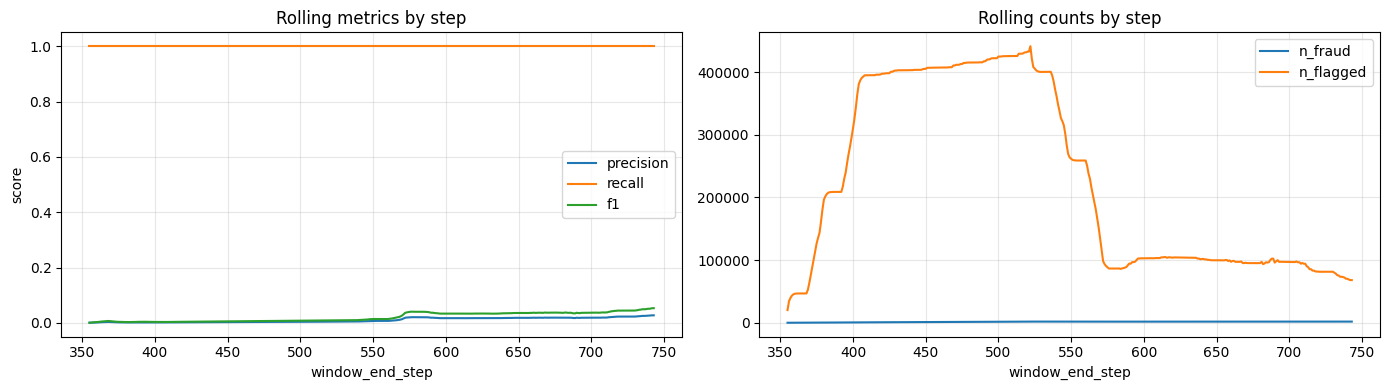

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(rolling['window_end_step'], rolling['precision'], label='precision')
axes[0].plot(rolling['window_end_step'], rolling['recall'], label='recall')
axes[0].plot(rolling['window_end_step'], rolling['f1'], label='f1')
axes[0].set_title('Rolling metrics by step')
axes[0].set_xlabel('window_end_step')
axes[0].set_ylabel('score')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(rolling['window_end_step'], rolling['n_fraud'], label='n_fraud')
axes[1].plot(rolling['window_end_step'], rolling['n_flagged'], label='n_flagged')
axes[1].set_title('Rolling counts by step')
axes[1].set_xlabel('window_end_step')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5) Evidently dashboard

Xuat dashboard HTML de review drift + classification metrics.

In [19]:
dashboard_path = OUTPUT_DIR / 'monitoring_dashboard.html'
mon.build_evidently_dashboard(
    reference=reference,
    current=current,
    features=deployed_features,
    output_path=dashboard_path,
    max_rows=50000,
)
print('Saved dashboard:', dashboard_path)

Saved dashboard: d:\2026\SoICT_DataScience\Business_Intelligent\business-analysis-hust\Module_07\outputs\monitoring_dashboard.html


## 6) Retraining triggers

Ap dung trigger rule co ban:

- Drift fraction > 30%
- Precision < 70% baseline deployment
- Recall giam > 15 diem phan tram so voi baseline

In [20]:
trigger_summary = mon.evaluate_triggers(
    drift_summary=drift_summary,
    rolling_metrics=rolling,
    baseline_metrics=policy['metrics_at_threshold'],
    config=mon.TriggerConfig(),
)

trigger_path = OUTPUT_DIR / 'trigger_summary.json'
trigger_path.write_text(json.dumps(trigger_summary, indent=2, default=float), encoding='utf-8')

summary_md = OUTPUT_DIR / 'monitor_summary.md'
mon.write_summary_markdown(
    output_path=summary_md,
    reference=reference,
    current=current,
    drift_summary=drift_summary,
    rolling_metrics=rolling,
    trigger_summary=trigger_summary,
)

print('Should retrain:', trigger_summary['should_retrain'])
print('Saved trigger summary:', trigger_path)
print('Saved markdown summary:', summary_md)
trigger_summary

Should retrain: True
Saved trigger summary: d:\2026\SoICT_DataScience\Business_Intelligent\business-analysis-hust\Module_07\outputs\trigger_summary.json
Saved markdown summary: d:\2026\SoICT_DataScience\Business_Intelligent\business-analysis-hust\Module_07\outputs\monitor_summary.md


{'baseline_metrics': {'AUC_PR': 0.866,
  'threshold*': 0.004,
  'precision': 0.0128,
  'recall': 0.9988,
  'F1': 0.0252,
  'net_cost': 4534131.0,
  'n_fp': 328519.0,
  'savings_vs_approve_all': 6698060635.0},
 'latest_window_metrics': {'window_start_step': 576.0,
  'window_end_step': 743.0,
  'n_transactions': 68117.0,
  'n_fraud': 1854.0,
  'n_flagged': 68064.0,
  'precision': 0.02723906911142454,
  'recall': 1.0,
  'f1': 0.05303355359134987,
  'average_precision': 0.8917600226523579,
  'fraud_rate': 0.027217875126620373},
 'triggers': {'drift_fraction': {'value': 0.5405405405405406,
   'threshold': 0.3,
   'breached': True},
  'precision_drop': {'value': 0.02723906911142454,
   'threshold': 0.00896,
   'breached': False},
  'recall_drop': {'value': 1.0, 'threshold': 0.8488, 'breached': False},
  'scheduled_retrain': {'policy': 'review monthly even without drift, because fraud patterns evolve',
   'breached': False}},
 'should_retrain': True}

## 7) Ket luan cho Module 7

Checklist nop bai:

- Co drift monitoring report (`drift_summary.csv` + Evidently HTML)
- Co performance monitoring theo rolling window (`rolling_metrics.csv`)
- Co retraining trigger policy va ket qua (`trigger_summary.json`)
- Co file tong hop de doc nhanh (`monitor_summary.md`)